DCE ANALYSIS - VERSION 1
DCE Element Building Block Formulation

Material: μ=80.0 GPa, ν=0.300
Crack: 2a=6.0 mm, θ=0.0°
Stress: σ_xx=0.0 MPa, σ_yy=100.0 MPa, σ_xy=0.0 MPa
Dislocations per element: 15

DCE ANALYSIS - VERSION 1
Using DCE elements as building blocks

Mixed-mode DCE solution:
  Number of DCE elements: 2
  Total dislocations: 30 (per mode)
    Element 0: NEGATIVE, n=15
    Element 1: POSITIVE, n=15
  Applied stress (local):
    σ_11 = 0.00 MPa
    σ_22 = 100.00 MPa (normal)
    σ_12 = 0.00 MPa (shear)

DEBUG: Burgers vectors (signed values from solver)
Element 0 (NEGATIVE):
  Mode-I range: [191.03, 4203.73] nm
  Mode-II range: [0.00, 0.00] nm
Element 1 (POSITIVE):
  Mode-I range: [-579.33, 86.06] nm
  Mode-II range: [-0.00, -0.00] nm

RESULTS:
  K_I (DCE):         0.000 MPa√m
  K_I (analytical):  9.708 MPa√m
  Error (Mode-I):    100.00%
  K_II (DCE):        2.743 MPa√m
  K_II (analytical): 0.000 MPa√m
  Error (Mode-II):   0.00%


1. DCE element structure...


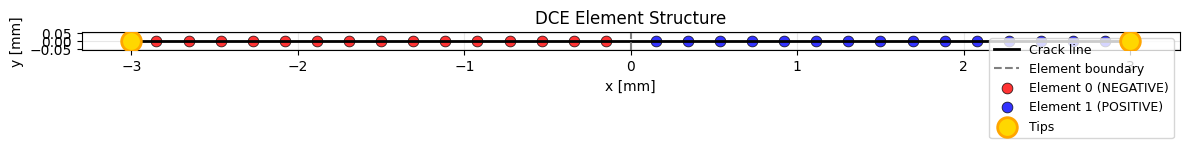


2. Summary...


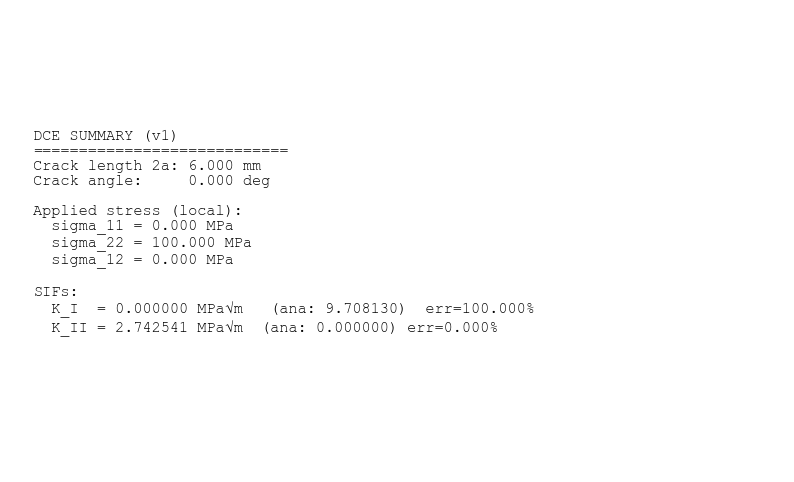


3. Stress fields...


findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXGeneral'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXNonUnicode'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeOneSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeTwoSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeThreeSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFourSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['STIXSizeFiveSym'] not found. Falling back to DejaVu Sans.
findfont: Font family ['cmsy10'] not

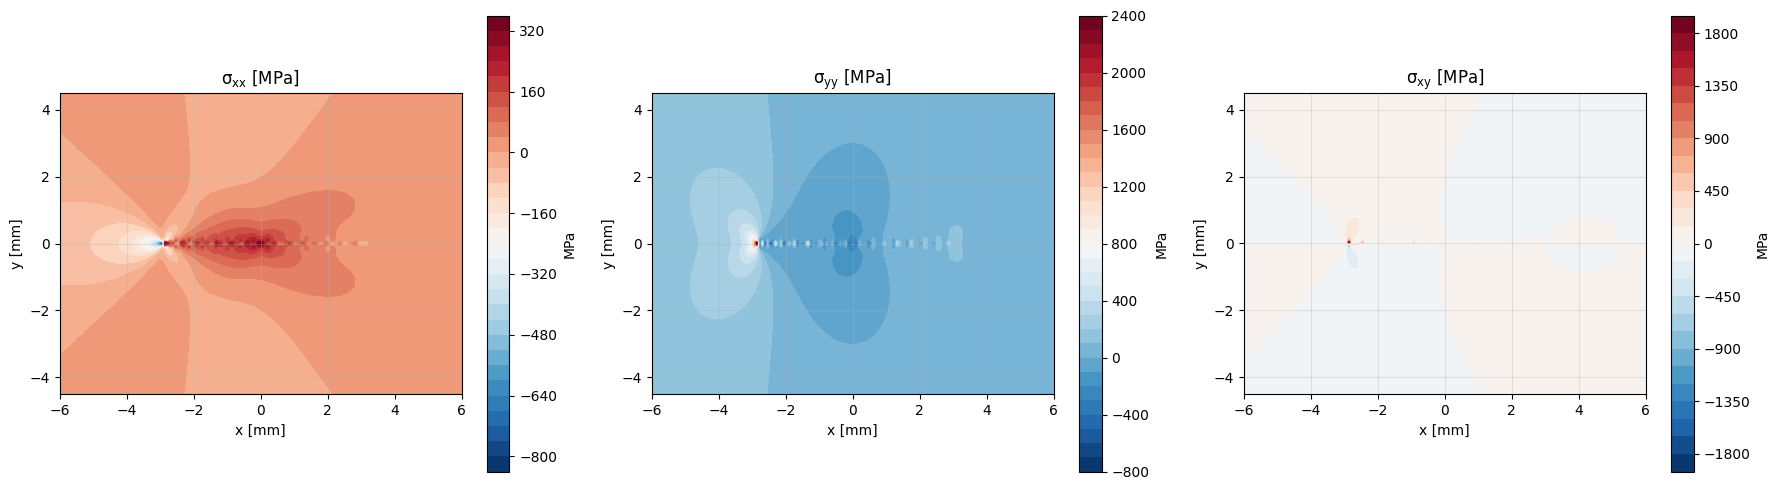


4. Crack displacement...


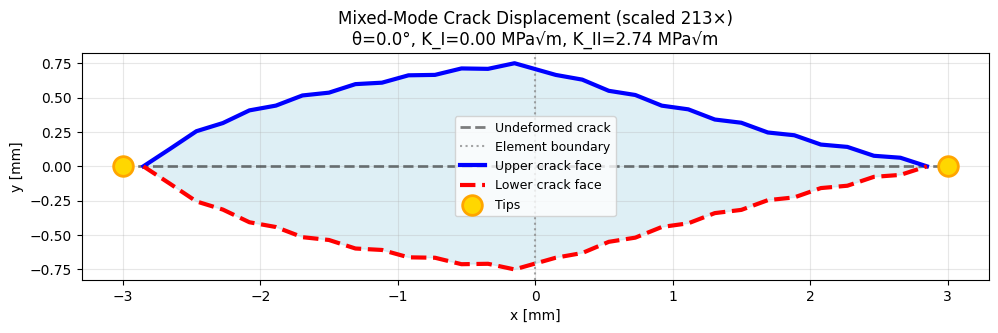


ANALYSIS COMPLETE
Results saved to: c:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\jupyter_notebooks\dce_results_v1

DEBUG: Burgers vectors
Element 0 (NEGATIVE):
  Mode-I range: [191.03, 4203.73] nm
  Mode-II range: [0.00, 0.00] nm
Element 1 (POSITIVE):
  Mode-I range: [-579.33, 86.06] nm
  Mode-II range: [-0.00, -0.00] nm


In [1]:
"""
DCE Analysis - Version 1
DCE Element formulation with building blocks
"""

# %% Imports
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import os, sys


# Ensure CrackUtils is on path
nb_dir = os.path.abspath(os.getcwd())
root   = os.path.abspath(os.path.join(nb_dir, ".."))
if root not in sys.path:
    sys.path.insert(0, root)
    
# Import DCE modules
from CrackUtils.dce_calculations_v1_old import (
    Material, Crack, AppliedStress, DCECalculatorV1
)
from CrackUtils.dce_plotting_v1 import DCEPlotterV1

%matplotlib inline
plt.rcParams['figure.dpi'] = 100

# %% INPUT PARAMETERS

# Material
material = Material(
    mu=80e9,
    nu=0.3
)

# Crack
crack = Crack(
    length=6e-3,
    angle=np.deg2rad(0),
    center=(0.0, 0.0)
)

# Applied Stress (GLOBAL)
stress = AppliedStress(
    sigma_xx=0e6,
    sigma_yy=100e6,
    sigma_xy=0e6  # Shear for Mode-II
)

# Parameters
n_dislocations_per_element = 15  # N dislocations per element per mode
tip_fraction = 0.95
grid_size = 150

# Output
output_dir = Path('./dce_results_v1')
output_dir.mkdir(exist_ok=True)

print("="*70)
print("DCE ANALYSIS - VERSION 1")
print("DCE Element Building Block Formulation")
print("="*70)
print(f"\nMaterial: μ={material.mu/1e9:.1f} GPa, ν={material.nu:.3f}")
print(f"Crack: 2a={crack.length*1e3:.1f} mm, θ={np.rad2deg(crack.angle):.1f}°")
print(f"Stress: σ_xx={stress.sigma_xx/1e6:.1f} MPa, σ_yy={stress.sigma_yy/1e6:.1f} MPa, σ_xy={stress.sigma_xy/1e6:.1f} MPa")
print(f"Dislocations per element: {n_dislocations_per_element}")
print("="*70)

# %% CALCULATIONS

calc = DCECalculatorV1(material, crack, stress)
results = calc.solve(n_dislocations_per_element=n_dislocations_per_element, 
                     tip_fraction=tip_fraction)

# %% PLOTTING

plotter = DCEPlotterV1(calc, results)

# 1. Element Structure
print("\n1. DCE element structure...")
fig_struct = plotter.plot_element_structure(
    output_path=output_dir / 'element_structure_v1.png'
)
plt.show()

# 2. Summary
print("\n2. Summary...")
fig_summary = plotter.plot_summary(
    output_path=output_dir / 'summary_v1.png'
)
plt.show()

# 3. Stress Fields
print("\n3. Stress fields...")
fig_stress = plotter.plot_stress_fields(
    grid_size=grid_size,
    output_path=output_dir / 'stress_fields_v1.png'
)
plt.show()

# 4. Crack Displacement
print("\n4. Crack displacement...")
fig_disp = plotter.plot_crack_displacement(
    output_path=output_dir / 'crack_displacement_v1.png'
)
plt.show()

print("\n" + "="*70)
print("ANALYSIS COMPLETE")
print(f"Results saved to: {output_dir.absolute()}")
print("="*70)

# Add to solve_mixed_mode after solving:
print(f"\nDEBUG: Burgers vectors")
for elem_idx, elem in enumerate(results['dce_elements']):
    print(f"Element {elem_idx} ({elem.polarity.name}):")
    print(f"  Mode-I range: [{np.min(elem.b_mode_I)*1e9:.2f}, {np.max(elem.b_mode_I)*1e9:.2f}] nm")
    print(f"  Mode-II range: [{np.min(elem.b_mode_II)*1e9:.2f}, {np.max(elem.b_mode_II)*1e9:.2f}] nm")
    



In [2]:
import CrackUtils.dce_plotting_v1 as p
print("Loaded from:", p.__file__)
print("Text contains plot_element_structure:",
      "def plot_element_structure" in open(p.__file__, "r", encoding="utf-8").read())
print("plot_* methods:", [m for m in dir(p.DCEPlotterV1) if m.startswith("plot_")])


Loaded from: c:\Users\Owner\Documents\Repos\Fracture\MulticracksCpp\CrackUtils\dce_plotting_v1.py
Text contains plot_element_structure: True
plot_* methods: []
